In [1]:
from src.feature_engineering import engineer_features

df_features, engineer = engineer_features(df_clean)

print(df_features.shape)
print(df_features.head())

NameError: name 'df_clean' is not defined

In [3]:
print('df_clean' in globals())

False


In [4]:
import pandas as pd

df_clean = pd.read_csv(
    "data/processed/clean_transactions.csv",
    parse_dates=["timestamp"]
)

print(df_clean.shape)

(250000, 15)


In [5]:
from src.data_loader import load_and_clean_data

df_clean, cleaner = load_and_clean_data(
    "data/raw_transactions.csv"
)

print(df_clean.shape)

📥 LOADING AND CLEANING DATA

📂 Loading data from data/raw_transactions.csv...
✅ Loaded 250,000 records with 15 columns
🔍 Handling missing values...
✅ Missing values handled
Missing values: 250 → 0
🔍 Removing duplicates...
✅ Duplicates removed: 0 records
🔍 Handling outliers...
✅ Outliers handled: 13119 values capped

📊 DATA QUALITY REPORT
Total Records: 250,000
Duplicates Removed: 0
Missing Values: 250 → 0
Outliers Handled: 13119
Fraud Cases: 10,000
Fraud Percentage: 4.00%
(250000, 15)


In [6]:
from src.feature_engineering import engineer_features

df_features, engineer = engineer_features(df_clean)

print(df_features.shape)

print("\nCreated Features:")
print(engineer.get_feature_list())


🔧 FEATURE ENGINEERING PIPELINE
⏰ Creating time-based features...
💰 Creating amount-based features...
👤 Creating customer features...
📊 Creating frequency features...
🎯 Creating behavioral features...
🔗 Creating interaction features...
📏 Scaling numerical features...

✅ Features Created: 16
✅ Total Columns: 31
(250000, 31)

Created Features:
['is_night_time', 'is_business_hours', 'is_weekend', 'amount_log', 'high_amount_flag', 'amount_category', 'customer_avg_amount', 'customer_std_amount', 'customer_max_amount', 'unusual_amount_for_customer', 'customer_transaction_count', 'merchant_transaction_count', 'category_transaction_count', 'card_type_numeric', 'transaction_type_numeric', 'frequency_amount_ratio']


In [7]:
print(df_clean.shape)
print(df_features.shape)
print(len(engineer.get_feature_list()))

(250000, 15)
(250000, 31)
16


In [9]:
import os

os.makedirs(
    "data/processed",
    exist_ok=True
)

df_features.to_csv(
    "data/processed/feature_engineered_transactions.csv",
    index=False
)

print("✅ Feature engineered dataset saved")

✅ Feature engineered dataset saved


In [10]:
from sklearn.model_selection import train_test_split

feature_cols = [
    col for col in df_features.columns
    if col not in [
        'transaction_id',
        'customer_id',
        'merchant_id',
        'timestamp',
        'merchant_category',
        'card_type',
        'transaction_type',
        'country',
        'device_type',
        'is_fraud'
    ]
]

X = df_features[feature_cols]
y = df_features['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(200000, 21)
(50000, 21)


In [11]:
print(y_train.value_counts())

print("\n")

print(y_test.value_counts())

is_fraud
0    192000
1      8000
Name: count, dtype: int64


is_fraud
0    48000
1     2000
Name: count, dtype: int64


In [14]:
from src.model_trainer import ModelTrainer

print([
    x for x in dir(ModelTrainer)
    if not x.startswith("__")
])

['compare_models', 'evaluate_model', 'save_best_model', 'train_logistic_regression', 'train_random_forest', 'train_xgboost']


In [15]:
from src.model_trainer import train_models

trainer, comparison, best_model_name = train_models(
    X_train,
    X_test,
    y_train,
    y_test
)


🚀 MODEL TRAINING

🔹 Training Logistic Regression...

Logistic Regression
Accuracy : 0.7575
Precision: 0.0917
Recall   : 0.5685
F1 Score : 0.1579
ROC-AUC  : 0.7182

🔹 Training Random Forest...

Random Forest
Accuracy : 0.9417
Precision: 0.2050
Recall   : 0.1590
F1 Score : 0.1791
ROC-AUC  : 0.6704

🔹 Training XGBoost...

XGBoost
Accuracy : 0.8658
Precision: 0.1252
Recall   : 0.3930
F1 Score : 0.1899
ROC-AUC  : 0.6869


MODEL COMPARISON
                     accuracy  precision  recall        f1   roc_auc
Logistic Regression   0.75746   0.091686  0.5685  0.157906  0.718194
Random Forest         0.94170   0.205029  0.1590  0.179104  0.670440
XGBoost               0.86584   0.125159  0.3930  0.189855  0.686869


KeyError: 'XGBoost'

In [16]:
df_features.groupby("is_fraud")[
    "transaction_amount"
].mean()

is_fraud
0   -0.037925
1    0.910209
Name: transaction_amount, dtype: float64

In [17]:
df_features.groupby("is_fraud")[
    "high_amount_flag"
].mean()

is_fraud
0    0.223825
1    0.548000
Name: high_amount_flag, dtype: float64

In [18]:
comparison

NameError: name 'comparison' is not defined

In [19]:
X_train.columns.tolist()

['transaction_amount',
 'transaction_hour',
 'transaction_day',
 'transaction_month',
 'transaction_day_of_week',
 'is_night_time',
 'is_business_hours',
 'is_weekend',
 'amount_log',
 'high_amount_flag',
 'amount_category',
 'customer_avg_amount',
 'customer_std_amount',
 'customer_max_amount',
 'unusual_amount_for_customer',
 'customer_transaction_count',
 'merchant_transaction_count',
 'category_transaction_count',
 'card_type_numeric',
 'transaction_type_numeric',
 'frequency_amount_ratio']

In [20]:
pd.crosstab(
    df_features["country"],
    df_features["is_fraud"]
)

is_fraud,0,1
country,,
Australia,24139,0
Brazil,23908,0
Canada,23875,0
China,0,3315
France,23970,0
Germany,24110,0
India,23846,0
Mexico,23930,0
Nigeria,23933,3375


In [21]:
df_features.groupby("country")["is_fraud"].mean()\
          .sort_values(ascending=False)

country
China        1.00000
Russia       1.00000
Nigeria      0.12359
Australia    0.00000
Brazil       0.00000
Canada       0.00000
France       0.00000
Germany      0.00000
India        0.00000
Mexico       0.00000
UK           0.00000
USA          0.00000
Name: is_fraud, dtype: float64

In [22]:
df_model = pd.get_dummies(
    df_features,
    columns=[
        "country",
        "merchant_category",
        "device_type"
    ],
    drop_first=True
)

In [24]:
categorical_cols = [
    "country",
    "merchant_category",
    "device_type"
]

df_model = pd.get_dummies(
    df_features,
    columns=categorical_cols,
    drop_first=True
)

print(df_model.shape)

(250000, 54)


In [25]:
from sklearn.model_selection import train_test_split

feature_cols = [
    col for col in df_model.columns
    if col not in [
        'transaction_id',
        'customer_id',
        'merchant_id',
        'timestamp',
        'card_type',
        'transaction_type',
        'country',
        'merchant_category',
        'device_type',
        'is_fraud'
    ]
]

X = df_model[feature_cols]

y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(200000, 47)
(50000, 47)


In [26]:
from src.model_trainer import train_models

trainer, comparison, best_model_name = train_models(
    X_train,
    X_test,
    y_train,
    y_test
)


🚀 MODEL TRAINING

🔹 Training Logistic Regression...

Logistic Regression
Accuracy : 0.9058
Precision: 0.2980
Recall   : 1.0000
F1 Score : 0.4591
ROC-AUC  : 0.9905

🔹 Training Random Forest...

Random Forest
Accuracy : 0.9786
Precision: 0.7019
Recall   : 0.8065
F1 Score : 0.7506
ROC-AUC  : 0.9895

🔹 Training XGBoost...

XGBoost
Accuracy : 0.9637
Precision: 0.5285
Recall   : 0.8625
F1 Score : 0.6554
ROC-AUC  : 0.9894


MODEL COMPARISON
                     accuracy  precision  recall        f1   roc_auc
Logistic Regression   0.90576   0.297974  1.0000  0.459137  0.990509
Random Forest         0.97856   0.701915  0.8065  0.750582  0.989493
XGBoost               0.96372   0.528493  0.8625  0.655395  0.989352


KeyError: 'Random Forest'

In [28]:
from src.model_trainer import train_models

trainer, comparison, best_model_name = train_models(
    X_train,
    X_test,
    y_train,
    y_test
)


🚀 MODEL TRAINING

🔹 Training Logistic Regression...

Logistic Regression
Accuracy : 0.9058
Precision: 0.2980
Recall   : 1.0000
F1 Score : 0.4591
ROC-AUC  : 0.9905

🔹 Training Random Forest...

Random Forest
Accuracy : 0.9786
Precision: 0.7019
Recall   : 0.8065
F1 Score : 0.7506
ROC-AUC  : 0.9895

🔹 Training XGBoost...

XGBoost
Accuracy : 0.9637
Precision: 0.5285
Recall   : 0.8625
F1 Score : 0.6554
ROC-AUC  : 0.9894


MODEL COMPARISON
                     accuracy  precision  recall        f1   roc_auc
Logistic Regression   0.90576   0.297974  1.0000  0.459137  0.990509
Random Forest         0.97856   0.701915  0.8065  0.750582  0.989493
XGBoost               0.96372   0.528493  0.8625  0.655395  0.989352


KeyError: 'Random Forest'

In [29]:
import inspect
from src.model_trainer import ModelTrainer

print(inspect.getsource(ModelTrainer.save_best_model))

    
    def save_best_model(self):



In [35]:
import importlib
import src.model_trainer

importlib.reload(src.model_trainer)

from src.model_trainer import train_models

In [36]:
trainer, comparison, best_model_name = train_models(
    X_train,
    X_test,
    y_train,
    y_test
)

print(best_model_name)


🚀 MODEL TRAINING

🔹 Training Logistic Regression...

Logistic Regression
Accuracy : 0.9058
Precision: 0.2980
Recall   : 1.0000
F1 Score : 0.4591
ROC-AUC  : 0.9905

🔹 Training Random Forest...

Random Forest
Accuracy : 0.9786
Precision: 0.7019
Recall   : 0.8065
F1 Score : 0.7506
ROC-AUC  : 0.9895

🔹 Training XGBoost...

XGBoost
Accuracy : 0.9637
Precision: 0.5285
Recall   : 0.8625
F1 Score : 0.6554
ROC-AUC  : 0.9894


MODEL COMPARISON
                     accuracy  precision  recall        f1   roc_auc
Logistic Regression   0.90576   0.297974  1.0000  0.459137  0.990509
Random Forest         0.97856   0.701915  0.8065  0.750582  0.989493
XGBoost               0.96372   0.528493  0.8625  0.655395  0.989352

✅ Best Model Saved: random_forest
random_forest



🏆 Top Features
                   Feature  Importance
29          country_Russia    0.221937
23           country_China    0.220248
28         country_Nigeria    0.128421
0       transaction_amount    0.044190
8               amount_log    0.042070
26           country_India    0.026749
25         country_Germany    0.026046
30              country_UK    0.025791
31             country_USA    0.025085
10         amount_category    0.024235
24          country_France    0.024163
27          country_Mexico    0.024156
21          country_Brazil    0.023550
22          country_Canada    0.022289
20  frequency_amount_ratio    0.019675
9         high_amount_flag    0.019200
12     customer_std_amount    0.009695
11     customer_avg_amount    0.009611
13     customer_max_amount    0.009463
2          transaction_day    0.006775


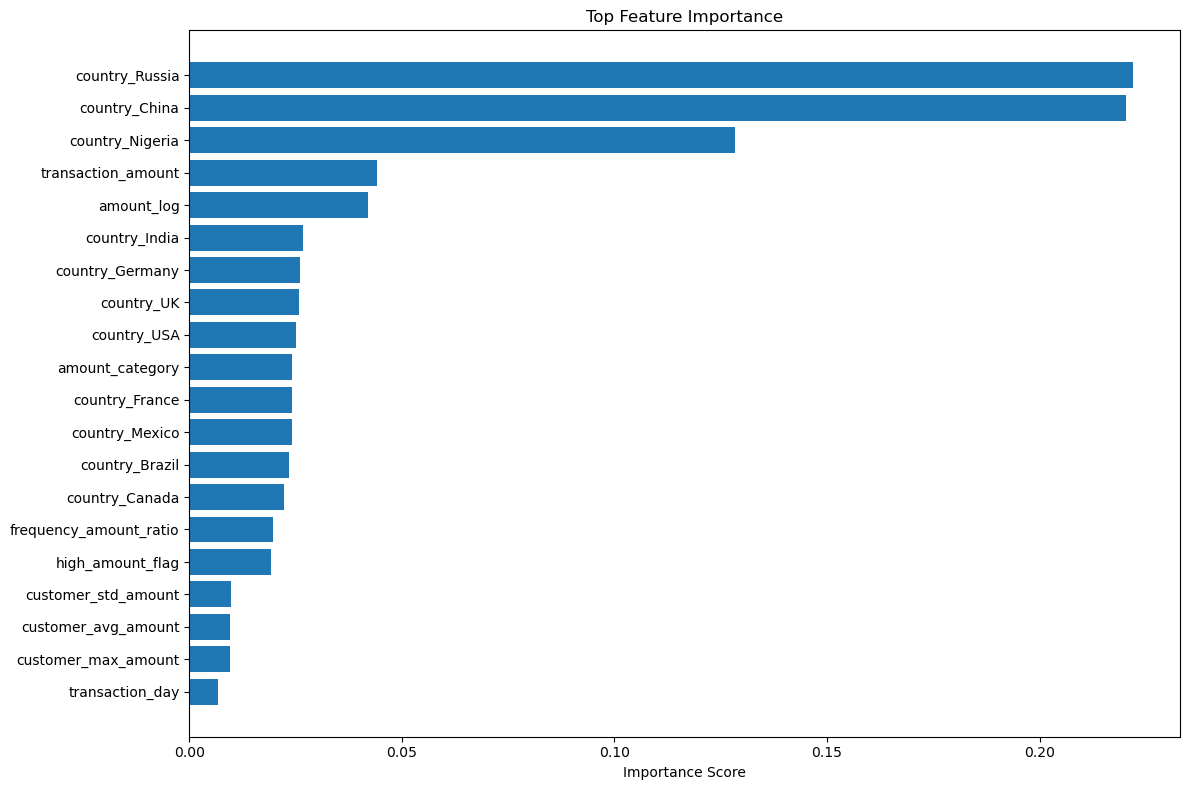

,Feature,Importance
29,country_Russia,0.221937
23,country_China,0.220248
28,country_Nigeria,0.128421
0,transaction_amount,0.044190
8,amount_log,0.042070
26,country_India,0.026749
25,country_Germany,0.026046
30,country_UK,0.025791
31,country_USA,0.025085
10,amount_category,0.024235


In [37]:
from src.feature_importance import plot_feature_importance

rf_model = trainer.models["random_forest"]

importance_df = plot_feature_importance(
    rf_model,
    X_train.columns
)

importance_df.head(20)

In [38]:
from src.feature_analysis import analyze_top_features

top_features = analyze_top_features(
    importance_df
)

top_features.head()


TOP FEATURE ANALYSIS
1. country_Russia (0.2219)
2. country_China (0.2202)
3. country_Nigeria (0.1284)
4. transaction_amount (0.0442)
5. amount_log (0.0421)
6. country_India (0.0267)
7. country_Germany (0.0260)
8. country_UK (0.0258)
9. country_USA (0.0251)
10. amount_category (0.0242)
11. country_France (0.0242)
12. country_Mexico (0.0242)
13. country_Brazil (0.0235)
14. country_Canada (0.0223)
15. frequency_amount_ratio (0.0197)
16. high_amount_flag (0.0192)
17. customer_std_amount (0.0097)
18. customer_avg_amount (0.0096)
19. customer_max_amount (0.0095)
20. transaction_day (0.0068)

✅ Saved: reports/top_20_features.csv


,Feature,Importance
29,country_Russia,0.221937
23,country_China,0.220248
28,country_Nigeria,0.128421
0,transaction_amount,0.044190
8,amount_log,0.042070


In [1]:
import shap

print(shap.__version__)

0.51.0


In [2]:
import shap

print("Step 1")

explainer = shap.TreeExplainer(rf_model)

print("Step 2")

X_sample = X_test.sample(100, random_state=42)

shap_values = explainer.shap_values(X_sample)

print("Step 3")

Step 1


NameError: name 'rf_model' is not defined

In [3]:
print("trainer" in globals())

False


In [4]:
import pickle

with open(
    "models/random_forest.pkl",
    "rb"
) as f:

    rf_model = pickle.load(f)

print(type(rf_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [5]:
import shap

print("Step 1")

explainer = shap.TreeExplainer(rf_model)

print("Step 2")

X_sample = X_test.sample(
    100,
    random_state=42
)

shap_values = explainer.shap_values(
    X_sample
)

print("Step 3")

Step 1
Step 2


NameError: name 'X_test' is not defined

In [6]:
print("X_test" in globals())

False


In [7]:
from sklearn.model_selection import train_test_split

X = df_model[feature_cols]
y = df_model["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

NameError: name 'df_model' is not defined

In [8]:
print("trainer" in globals())
print("rf_model" in globals())
print("X_test" in globals())

False
True
False


In [9]:
print("df_features" in globals())

False


In [10]:
import os

os.path.exists(
    "data/processed/fraud_features.csv"
)

False

In [11]:
print("df_raw" in globals())
print("df_clean" in globals())
print("df_features" in globals())

False
False
False


In [12]:
import os

print(os.listdir("data"))

['processed', 'raw', 'raw_transactions.csv']


In [13]:
import os

print(os.listdir("data/processed"))

['clean_transactions.csv', 'feature_engineered_transactions.csv']


In [14]:
import pandas as pd

df_features = pd.read_csv(
    "data/processed/feature_engineered_transactions.csv"
)

print(df_features.shape)
df_features.head()

(250000, 31)


,transaction_id,timestamp,customer_id,merchant_id,transaction_amount,merchant_category,card_type,transaction_type,country,device_type,...,customer_avg_amount,customer_std_amount,customer_max_amount,unusual_amount_for_customer,customer_transaction_count,merchant_transaction_count,category_transaction_count,card_type_numeric,transaction_type_numeric,frequency_amount_ratio
0,TXN_0000001,2024-10-16 03:01:00,CUST_010607,MERCH_09995,-0.592825,Airlines,Credit,Online,USA,Tablet,...,0.925135,0.207993,0.576158,0,-0.445976,0.809865,-0.313392,1,0,-0.205757
1,TXN_0000002,2023-10-09 07:14:00,CUST_044501,MERCH_06467,2.284526,Clothing,Credit,Offline,Brazil,POS,...,0.436611,0.273973,0.954407,0,0.891887,0.003000,-1.155417,1,1,-0.300143
2,TXN_0000003,2023-05-23 23:06:00,CUST_027157,MERCH_05502,0.366888,Clothing,Debit,Online,Australia,Desktop,...,0.844576,-0.144003,0.084617,0,-0.891930,1.011581,-1.155417,0,0,-0.295680
3,TXN_0000004,2024-11-23 23:57:00,CUST_004958,MERCH_02380,-0.090392,Pharmacy,Debit,Mobile,USA,Tablet,...,0.729451,0.846303,1.134803,0,0.891887,0.809865,0.496555,0,2,-0.227620
4,TXN_0000005,2024-07-12 02:37:00,CUST_048904,MERCH_05684,-0.932151,Entertainment,Credit,Mobile,France,POS,...,0.359149,0.867600,1.134803,0,1.337841,1.616730,0.849404,1,2,0.284715


In [15]:
categorical_cols = [
    "country",
    "merchant_category",
    "device_type"
]

df_model = pd.get_dummies(
    df_features,
    columns=categorical_cols,
    drop_first=True
)

print(df_model.shape)

(250000, 54)


In [16]:
from sklearn.model_selection import train_test_split

feature_cols = [
    col for col in df_model.columns
    if col != "is_fraud"
]

X = df_model[feature_cols]
y = df_model["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(200000, 53)
(50000, 53)


In [17]:
import pickle

with open(
    "models/random_forest.pkl",
    "rb"
) as f:

    rf_model = pickle.load(f)

print(type(rf_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [18]:
import shap

explainer = shap.TreeExplainer(
    rf_model
)

X_sample = X_test.sample(
    100,
    random_state=42
)

shap_values = explainer.shap_values(
    X_sample
)

print("✅ SHAP Working")

ValueError: could not convert string to float: 'TXN_0248448'

In [19]:
print(X_test.columns.tolist())

['transaction_id', 'timestamp', 'customer_id', 'merchant_id', 'transaction_amount', 'card_type', 'transaction_type', 'transaction_hour', 'transaction_day', 'transaction_month', 'transaction_day_of_week', 'is_night_time', 'is_business_hours', 'is_weekend', 'amount_log', 'high_amount_flag', 'amount_category', 'customer_avg_amount', 'customer_std_amount', 'customer_max_amount', 'unusual_amount_for_customer', 'customer_transaction_count', 'merchant_transaction_count', 'category_transaction_count', 'card_type_numeric', 'transaction_type_numeric', 'frequency_amount_ratio', 'country_Brazil', 'country_Canada', 'country_China', 'country_France', 'country_Germany', 'country_India', 'country_Mexico', 'country_Nigeria', 'country_Russia', 'country_UK', 'country_USA', 'merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Entertainment', 'merchant_category_Gas Station', 'merchant_category_Grocery', 'merchant_category_Healthcare', 'merchant_category_Hotel', 'merchant_catego

In [20]:
feature_cols = [
    col for col in df_model.columns
    if col not in [
        'transaction_id',
        'customer_id',
        'merchant_id',
        'timestamp',
        'card_type',
        'transaction_type',
        'is_fraud'
    ]
]

X = df_model[feature_cols]
y = df_model["is_fraud"]

print(X.shape)

(250000, 47)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_test.shape)

(50000, 47)


In [22]:
print(
    X_test.select_dtypes(include="object").columns.tolist()
)

[]


In [23]:
import shap

explainer = shap.TreeExplainer(rf_model)

X_sample = X_test.sample(
    100,
    random_state=42
)

shap_values = explainer.shap_values(
    X_sample
)

print("✅ SHAP Working")

✅ SHAP Working


In [24]:
from src.model_explainability import (
    generate_shap_explanations
)

X_sample = X_test.sample(
    100,
    random_state=42
)

shap_values = generate_shap_explanations(
    rf_model,
    X_sample
)

🔍 GENERATING SHAP EXPLANATIONS
✅ SHAP values generated
✅ Saved: reports/shap_summary.png
✅ Saved: reports/shap_bar.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [25]:
import os

print(os.path.exists("reports/shap_summary.png"))
print(os.path.exists("reports/shap_bar.png"))

True
True


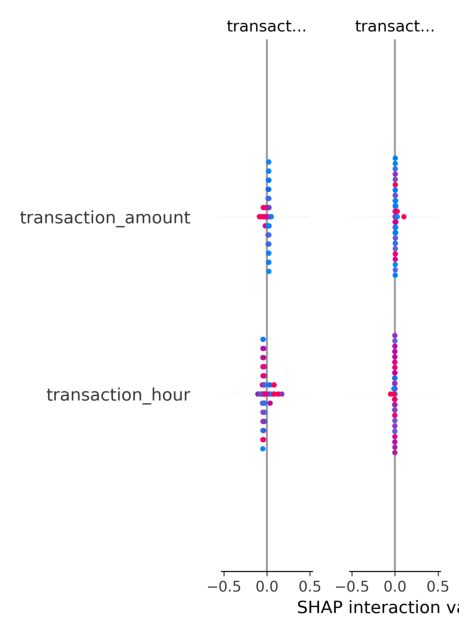

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("reports/shap_summary.png")

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

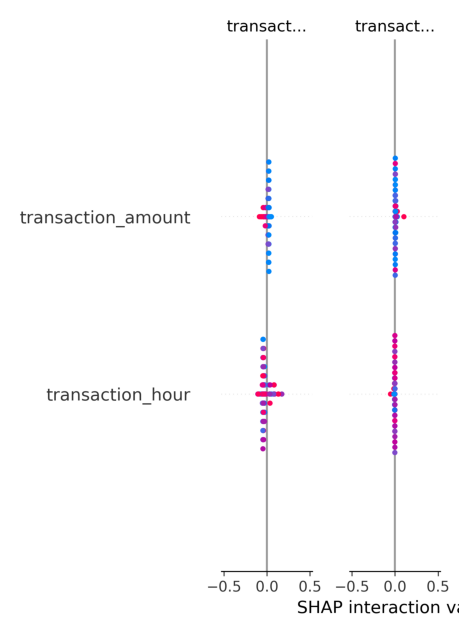

In [27]:
img = Image.open("reports/shap_bar.png")

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [28]:
print(type(shap_values))

try:
    print(shap_values.shape)
except:
    pass

<class 'numpy.ndarray'>
(100, 47, 2)


In [29]:
print(X_sample.shape)

(100, 47)


In [30]:
import shap

explainer = shap.TreeExplainer(rf_model)

shap_exp = explainer(X_sample)

print(shap_exp.values.shape)

(100, 47, 2)


In [3]:
import shap

print(shap.__version__)

0.51.0


In [5]:
print("rf_model" in globals())
print("X_sample" in globals())

False
False


In [7]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split

# Load feature engineered dataset
df_features = pd.read_csv(
    "data/processed/feature_engineered_transactions.csv"
)

# One-hot encoding
categorical_cols = [
    "country",
    "merchant_category",
    "device_type"
]

df_model = pd.get_dummies(
    df_features,
    columns=categorical_cols,
    drop_first=True
)

# Feature columns
feature_cols = [
    col for col in df_model.columns
    if col not in [
        "transaction_id",
        "customer_id",
        "merchant_id",
        "timestamp",
        "card_type",
        "transaction_type",
        "is_fraud"
    ]
]

X = df_model[feature_cols]
y = df_model["is_fraud"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Load model
with open(
    "models/random_forest.pkl",
    "rb"
) as f:
    rf_model = pickle.load(f)

print("✅ Recovery Complete")
print("X_test:", X_test.shape)
print("Model:", type(rf_model))

✅ Recovery Complete
X_test: (50000, 47)
Model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [8]:
import shap

X_sample = X_test.sample(
    100,
    random_state=42
)

explainer = shap.TreeExplainer(
    rf_model
)

shap_values = explainer.shap_values(
    X_sample
)

print(shap_values.shape)

(100, 47, 2)


In [9]:
import shap
import matplotlib.pyplot as plt

fraud_shap = shap_values[:, :, 1]

print(fraud_shap.shape)

(100, 47)


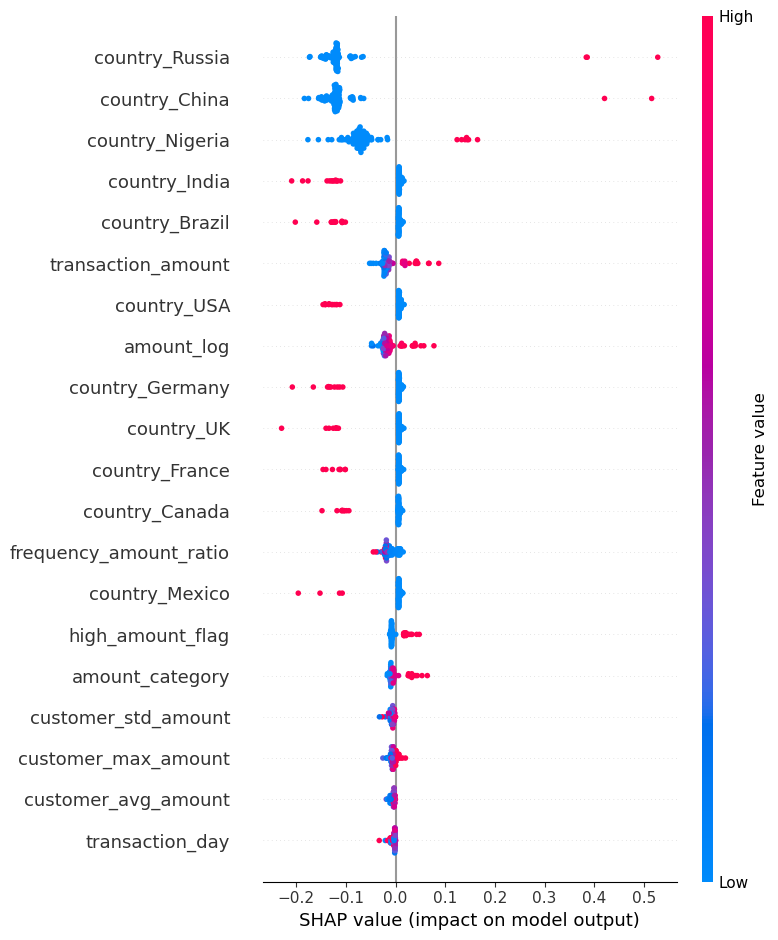

In [10]:
shap.summary_plot(
    fraud_shap,
    X_sample,
    max_display=20
)

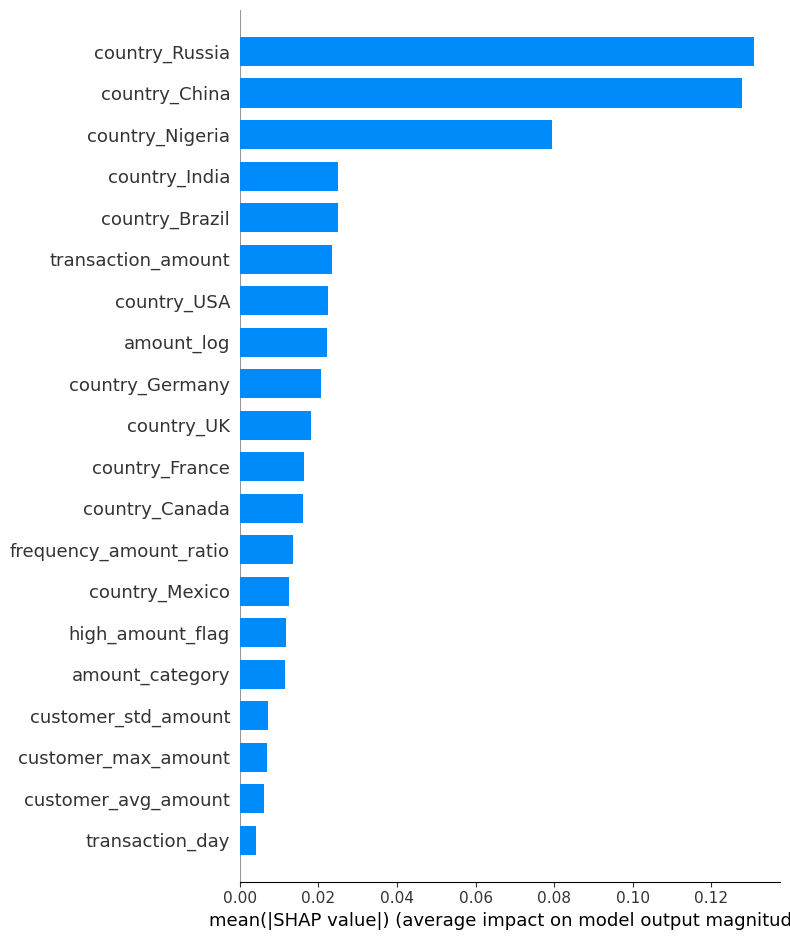

In [11]:
shap.summary_plot(
    fraud_shap,
    X_sample,
    plot_type="bar",
    max_display=20
)

In [13]:
shap.summary_plot(
    fraud_shap,
    X_sample,
    max_display=20,
    show=False
)

plt.savefig(
    "reports/shap_summary_fixed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Bar plot
shap.summary_plot(
    fraud_shap,
    X_sample,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.savefig(
    "reports/shap_bar_fixed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ SHAP plots saved")

✅ SHAP plots saved


In [14]:
from src.predict import FraudPredictor

predictor = FraudPredictor()

In [15]:
sample_transaction = X_test.iloc[[0]]

sample_transaction.head()

,transaction_amount,transaction_hour,transaction_day,transaction_month,transaction_day_of_week,is_night_time,is_business_hours,is_weekend,amount_log,high_amount_flag,...,merchant_category_Healthcare,merchant_category_Hotel,merchant_category_Online Retail,merchant_category_Pharmacy,merchant_category_Restaurant,merchant_category_Utilities,device_type_Desktop,device_type_Mobile,device_type_POS,device_type_Tablet
106835,0.182406,10.0,6,6,1,0,1,0,0.558529,0,...,False,False,False,False,False,False,False,False,False,True


In [16]:
result = predictor.predict(
    sample_transaction
)

print(result)

{'prediction': 'Genuine', 'fraud_probability': np.float64(0.0045)}


In [17]:
print(
    "Actual:",
    y_test.iloc[0]
)

print(
    "Prediction:",
    result
)

Actual: 0
Prediction: {'prediction': 'Genuine', 'fraud_probability': np.float64(0.0045)}


In [19]:
results = predictor.batch_predict(
    X_test.head(10)
)

results[
    [
        "fraud_probability",
        "prediction"
    ]
]

AttributeError: 'FraudPredictor' object has no attribute 'batch_predict'

In [21]:
import importlib
import src.predict

importlib.reload(src.predict)

from src.predict import FraudPredictor

predictor = FraudPredictor()

In [22]:
[
    x for x in dir(predictor)
    if not x.startswith("__")
]

['batch_predict', 'model', 'predict']

In [23]:
results = predictor.batch_predict(
    X_test.head(10)
)

results[
    [
        "fraud_probability",
        "prediction"
    ]
]

,fraud_probability,prediction
106835,0.004493,Genuine
108918,0.043263,Genuine
223404,0.006339,Genuine
69737,0.007867,Genuine
171670,0.021306,Genuine
84103,0.019458,Genuine
29926,0.011181,Genuine
196093,0.005447,Genuine
230170,0.006200,Genuine
220638,0.067778,Genuine


In [24]:
fraud_cases = X_test[y_test == 1]

fraud_results = predictor.batch_predict(
    fraud_cases.head(10)
)

fraud_results[
    [
        "fraud_probability",
        "prediction"
    ]
]

,fraud_probability,prediction
44764,0.931271,Fraud
84704,0.969316,Fraud
69165,0.606875,Fraud
137007,0.978853,Fraud
182553,0.437734,Genuine
128217,0.977147,Fraud
123642,0.933220,Fraud
71567,0.948907,Fraud
192922,0.984502,Fraud
76290,0.459803,Genuine


In [25]:
results = predictor.batch_predict(
    X_test
)

results.head()

,transaction_amount,transaction_hour,transaction_day,transaction_month,transaction_day_of_week,is_night_time,is_business_hours,is_weekend,amount_log,high_amount_flag,...,merchant_category_Online Retail,merchant_category_Pharmacy,merchant_category_Restaurant,merchant_category_Utilities,device_type_Desktop,device_type_Mobile,device_type_POS,device_type_Tablet,fraud_probability,prediction
106835,0.182406,10.0,6,6,1,0,1,0,0.558529,0,...,False,False,False,False,False,False,False,True,0.004493,Genuine
108918,-0.575878,14.0,20,3,2,0,1,0,-0.157539,0,...,False,False,False,False,False,False,False,True,0.043263,Genuine
223404,-0.704036,1.0,2,2,4,1,0,0,-0.375998,0,...,False,False,False,False,False,False,True,False,0.006339,Genuine
69737,-0.630062,7.0,25,1,2,0,0,0,-0.243001,0,...,False,False,False,False,False,False,True,False,0.007867,Genuine
171670,1.127264,0.0,16,2,3,1,0,0,1.008865,1,...,False,False,False,False,True,False,False,False,0.021306,Genuine


In [26]:
from src.report_generator import (
    FraudReportGenerator
)

reporter = FraudReportGenerator()

summary = reporter.generate_report(
    results
)

summary

✅ Fraud report generated
Total Transactions: 50,000
Fraud Transactions: 2,298
Fraud Rate: 4.60%


,Metric,Value
0,Total Transactions,50000.0
1,Fraud Transactions,2298.0
2,Fraud Rate (%),4.6


In [27]:
import os

print(
    os.listdir("reports")
)

['02_transaction_amount_distribution.png', '03_fraud_amount_comparison.png', '04_fraud_by_country.png', '05_fraud_by_transaction_type.png', '06_fraud_by_hour.png', '07_correlation_heatmap.png', 'feature_importance.png', 'fraud_predictions.csv', 'fraud_report.txt', 'fraud_summary.csv', 'shap_bar.png', 'shap_bar_fixed.png', 'shap_summary.png', 'shap_summary_fixed.png', 'top_20_features.csv', 'top_features.csv', 'top_fraud_cases.csv']


In [28]:
pd.read_csv(
    "reports/top_fraud_cases.csv"
).head()

,transaction_amount,transaction_hour,transaction_day,transaction_month,transaction_day_of_week,is_night_time,is_business_hours,is_weekend,amount_log,high_amount_flag,...,merchant_category_Online Retail,merchant_category_Pharmacy,merchant_category_Restaurant,merchant_category_Utilities,device_type_Desktop,device_type_Mobile,device_type_POS,device_type_Tablet,fraud_probability,prediction
0,2.454508,15.0,28,2,2,0,1,0,1.392904,1,...,False,False,False,True,False,False,False,True,0.997897,Fraud
1,2.454508,13.0,6,6,3,0,1,0,1.392904,1,...,False,False,False,False,False,False,True,False,0.997503,Fraud
2,2.454508,4.0,9,6,4,1,0,0,1.392904,1,...,False,False,False,False,False,False,False,True,0.997484,Fraud
3,2.454508,10.0,24,7,0,0,1,0,1.392904,1,...,False,True,False,False,False,True,False,False,0.997050,Fraud
4,2.454508,16.0,9,6,6,0,1,1,1.392904,1,...,False,True,False,False,True,False,False,False,0.997008,Fraud
